# E-Scooters & Urban Congestion in Chicago

# Name: Robin Nguyen, Tommy Eaton, Yuqing

**This project investigates whether the presence of high-density e-scooter fleets correlates with changes in traffic congestion levels across Chicago’s community areas. The team uses openly available data from the City of Chicago data portal, joining e-scooter trip records to Chicago Traffic Tracker congestion estimates by region, and will run a regression analysis controlling for key confounders across the 2022–2025 timeframe.**

### Import libraries

In [ ]:
# Core Libraries
!pip install statsmodels
!pip install xgboost
import pandas as pd  # Data manipulation
import numpy as np  # Numerical computations
import os
import glob
import re
import warnings
import statsmodels.api as sm
import matplotlib.pyplot as plt
from statsmodels.stats.outliers_influence import variance_inflation_factor

# Visualization Libraries
import matplotlib.pyplot as plt  # Plotting
import seaborn as sns  # Advanced visualization
from matplotlib.ticker import NullFormatter, FuncFormatter  # Formatting

# Machine Learning Libraries
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    classification_report,
)
from sklearn.feature_extraction.text import TfidfVectorizer, CountVectorizer, TfidfTransformer
from sklearn.pipeline import Pipeline
from sklearn.utils import resample, shuffle
from sklearn.tree import export_text
from xgboost import XGBRegressor
from sklearn.inspection import PartialDependenceDisplay
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 10.3/10.3 MB 63.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 233.3/233.3 kB 23.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 131.7/131.7 MB 9.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 300.2/300.2 MB 1.2 MB/s eta 0:00:00


In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
#Import df
e_scooter_path = "/content/drive/My Drive/data 400/data/combined_data/cleaned_2022_2025data.csv"
congestion_path = "/content/drive/My Drive/data 400/data/congested_data/updated_congestion_cleaned.csv"
scooter_df= pd.read_csv(e_scooter_path)
congestion_df = pd.read_csv(congestion_path)

In [ ]:
#create copy
scooter_df_copy = scooter_df.copy()
congestion_df_copy = congestion_df.copy()

In [ ]:
# View df
scooter_df_copy.head()

,Trip ID,Start Time,End Time,Trip Distance,Trip Duration,Vendor,Start Community Area Number,End Community Area Number,Start Community Area Name,End Community Area Name,Start Centroid Location,End Centroid Location,Start Day of Week,End Day of Week,Start Date,End Date,Mapped Start Area Code,Mapped End Area Code,Trip Duration Minutes
0,173d3183-1009-7302-173d-318310097302,09:00:00,09:00:00,193,13,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.216667
1,173d3204-d8be-984c-173d-3204d8be984c,09:00:00,09:00:00,104,43,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.716667
2,173d326e-fe57-a9de-173d-326efe57a9de,09:00:00,09:00:00,156,36,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.600000
3,173d39b4-a033-a160-173d-39b4a033a160,09:00:00,10:00:00,"8,168","2,345",Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,39.083333
4,173d3deb-46d8-d67a-173d-3deb46d8d67a,10:00:00,10:00:00,51,42,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.700000


In [ ]:
# View df
congestion_df_copy.head()

,date,time_block,region_id,region_name,avg_speed_mph,avg_bus_count,avg_num_reads,congestion_level,description,num_readings
0,01/01/2022,00:00-03:59,1,Rogers Park - West Ridge,27.73,5.8,100.1,free_flow,North of Devon. Kedzie to Lake Shore,10
1,01/01/2022,04:00-07:59,1,Rogers Park - West Ridge,28.46,10.1,224.3,free_flow,North of Devon. Kedzie to Lake Shore,21
2,01/01/2022,08:00-11:59,1,Rogers Park - West Ridge,25.58,17.5,363.7,free_flow,North of Devon. Kedzie to Lake Shore,23
3,01/01/2022,12:00-15:59,1,Rogers Park - West Ridge,23.38,20.1,429.9,free_flow,North of Devon. Kedzie to Lake Shore,17
4,01/01/2022,16:00-19:59,1,Rogers Park - West Ridge,20.40,19.6,436.5,free_flow,North of Devon. Kedzie to Lake Shore,23


In [ ]:
# ── 1. Work from the existing copies ─────────────────────────
scooter    = scooter_df_copy.copy()
congestion = congestion_df_copy.copy()

print(f"Scooter shape:    {scooter.shape}")
print(f"Congestion shape: {congestion.shape}")
display(scooter.head(3))
display(congestion.head(3))

Scooter shape:    (12805616, 19)
Congestion shape: (214410, 10)


,Trip ID,Start Time,End Time,Trip Distance,Trip Duration,Vendor,Start Community Area Number,End Community Area Number,Start Community Area Name,End Community Area Name,Start Centroid Location,End Centroid Location,Start Day of Week,End Day of Week,Start Date,End Date,Mapped Start Area Code,Mapped End Area Code,Trip Duration Minutes
0,173d3183-1009-7302-173d-318310097302,09:00:00,09:00:00,193,13,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.216667
1,173d3204-d8be-984c-173d-3204d8be984c,09:00:00,09:00:00,104,43,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.716667
2,173d326e-fe57-a9de-173d-326efe57a9de,09:00:00,09:00:00,156,36,Lyft,32.0,32.0,Loop,Loop,POINT (-87.62519186960115 41.87886594636445),POINT (-87.62519186960115 41.87886594636445),Tuesday,Tuesday,2022-05-10,2022-05-10,32.0,32.0,0.600000


,date,time_block,region_id,region_name,avg_speed_mph,avg_bus_count,avg_num_reads,congestion_level,description,num_readings
0,01/01/2022,00:00-03:59,1,Rogers Park - West Ridge,27.73,5.8,100.1,free_flow,North of Devon. Kedzie to Lake Shore,10
1,01/01/2022,04:00-07:59,1,Rogers Park - West Ridge,28.46,10.1,224.3,free_flow,North of Devon. Kedzie to Lake Shore,21
2,01/01/2022,08:00-11:59,1,Rogers Park - West Ridge,25.58,17.5,363.7,free_flow,North of Devon. Kedzie to Lake Shore,23


In [ ]:
# ── 2. Prepare scooter dataset ────────────────────────────────

# Combine Start Date and Start Time to get accurate datetimes
scooter['Start Time'] = pd.to_datetime(scooter['Start Date'].astype(str) + ' ' + scooter['Start Time'].astype(str), errors='coerce')

# Extract date and assign to 4-hour block (same labels as congestion)
scooter['date']     = scooter['Start Time'].dt.normalize()   # date only, no time
scooter['date_str'] = scooter['Start Time'].dt.strftime('%m/%d/%Y')

block_labels = {
    0: '00:00-03:59',
    1: '04:00-07:59',
    2: '08:00-11:59',
    3: '12:00-15:59',
    4: '16:00-19:59',
    5: '20:00-23:59',
}
scooter['time_block'] = (scooter['Start Time'].dt.hour // 4).map(block_labels)

# Map community area numbers to region IDs using the same lookup as before
# (same ca_to_region bridge table from the main notebook)
region_to_community_areas = {
    1:  [1, 2, 77],
    2:  [3, 4, 5],
    3:  [6, 7],
    4:  [8, 32, 33],
    5:  [9, 10, 11, 12, 13],
    6:  [14, 15, 16],
    7:  [17, 18, 19, 20],
    8:  [21, 22],
    9:  [23, 24],
    10: [25, 26, 27],
    11: [28, 29],
    12: [30, 31],
    13: [34, 35, 36, 37],
    14: [38, 39, 40],
    15: [41, 42, 43],
    16: [44, 45, 46],
    17: [47, 48, 49, 50],
    18: [51, 52, 53, 54, 55],
    19: [56, 57, 58, 59, 60],
    20: [61, 62, 63, 64],
    21: [65, 66, 67, 68],
    22: [69, 70, 71],
    23: [72, 73, 74, 75],
    24: [76],
    25: [1, 77],
    26: [4, 5],
    27: [6, 7],
    28: [22, 23],
    29: [32],
}
ca_to_region = {}
for region, areas in region_to_community_areas.items():
    for ca in areas:
        ca_to_region[ca] = region

scooter['region_id'] = scooter['Start Community Area Number'].map(ca_to_region)

# Convert distance and duration to numeric
scooter['Trip Distance'] = pd.to_numeric(scooter['Trip Distance'], errors='coerce')
scooter['Trip Duration'] = pd.to_numeric(scooter['Trip Duration'], errors='coerce')

# Drop rows with no region mapping or missing time block
scooter_clean = scooter.dropna(subset=['region_id', 'time_block', 'date']).copy()
scooter_clean['region_id'] = scooter_clean['region_id'].astype(int)

print(f"\nScooter rows after mapping: {len(scooter_clean):,}")
print(f"Unmapped rows dropped: {len(scooter) - len(scooter_clean):,}")



Scooter rows after mapping: 12,795,233
Unmapped rows dropped: 10,383


In [ ]:
# ── 3. Aggregate scooter trips into 4-hour blocks ────────────
print("\nAggregating scooter trips to 4-hour blocks...")

scooter_agg = (
    scooter_clean
    .groupby(['date', 'time_block', 'region_id'])
    .agg(
        trip_count       = ('Trip ID',       'count'),
        avg_distance_m   = ('Trip Distance', 'mean'),   # metres
        avg_duration_s   = ('Trip Duration', 'mean'),   # seconds
        unique_vendors   = ('Vendor',        'nunique'),
    )
    .reset_index()
)

scooter_agg['avg_distance_m'] = scooter_agg['avg_distance_m'].round(1)
scooter_agg['avg_duration_s'] = scooter_agg['avg_duration_s'].round(1)

print(f"Scooter aggregated shape: {scooter_agg.shape}")
display(scooter_agg.head(6))



Aggregating scooter trips to 4-hour blocks...
Scooter aggregated shape: (145457, 7)


,date,time_block,region_id,trip_count,avg_distance_m,avg_duration_s,unique_vendors
0,2022-05-10,08:00-11:59,4,5,452.2,214.4,1
1,2022-05-10,08:00-11:59,11,2,436.5,319.0,1
2,2022-05-10,08:00-11:59,27,1,471.0,168.0,1
3,2022-05-10,08:00-11:59,29,17,136.5,177.1,1
4,2022-05-10,12:00-15:59,4,9,494.5,468.0,1
5,2022-05-10,12:00-15:59,11,1,861.0,354.0,1


In [ ]:
# ── 4. Align date formats before join ─────────────────────────
# Convert congestion date to datetime
congestion['date'] = pd.to_datetime(congestion['date'], errors='coerce')

# Ensure scooter dates are timezone-naive to match congestion dates
scooter_agg['date'] = pd.to_datetime(scooter_agg['date']).dt.tz_localize(None)

# Both region_id are int — we're ready to join

print("\nJoining scooter and congestion datasets...")

merged = pd.merge(
    congestion,
    scooter_agg,
    on=['date', 'time_block', 'region_id'],
    how='inner'           # only keep blocks that exist in BOTH datasets
)

if len(merged) > 0:
    # Extract year for the train/test split
    merged['year'] = merged['date'].dt.year

    # Reformat date back to MM/DD/YYYY for readability in the output
    merged['date'] = merged['date'].dt.strftime('%m/%d/%Y')

    # Reorder columns cleanly
    merged = merged[[
        'date',
        'time_block',
        'region_id',
        'region_name',
        'description',
        'trip_count',
        'avg_distance_m',
        'avg_duration_s',
        'unique_vendors',
        'avg_speed_mph',
        'avg_bus_count',
        'avg_num_reads',
        'congestion_level',
        'num_readings',
        'year',
    ]]

    print(f"\nMerged dataset shape: {merged.shape}")
    print(f"Date range: {merged['date'].iloc[0]} → {merged['date'].iloc[-1]}")
    print(f"Regions covered: {merged['region_id'].nunique()}")
    display(merged.head(10))

    # Sanity check: rows per year
    print("\n── Rows per year ──")
    print(merged['year'].value_counts().sort_index())
else:
    print("\nMerge resulted in 0 rows. Please check that dates match between datasets.")



Joining scooter and congestion datasets...

Merged dataset shape: (120013, 15)
Date range: 05/10/2022 → 06/18/2025
Regions covered: 28


,date,time_block,region_id,region_name,description,trip_count,avg_distance_m,avg_duration_s,unique_vendors,avg_speed_mph,avg_bus_count,avg_num_reads,congestion_level,num_readings,year
0,05/10/2022,08:00-11:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,5,452.2,214.4,1,21.72,44.8,907.7,free_flow,24,2022
1,05/10/2022,12:00-15:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,9,494.5,468.0,1,20.78,39.9,813.0,free_flow,24,2022
2,05/10/2022,16:00-19:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,26,427.6,536.7,1,19.24,51.0,1001.0,moderate,24,2022
3,05/10/2022,20:00-23:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,10,83.0,509.7,1,22.86,23.9,526.3,free_flow,24,2022
4,05/10/2022,16:00-19:59,9,Austin,Roosevelt to North Ave. Austin to Cicero,4,20.5,265.7,1,24.40,25.9,551.4,free_flow,24,2022
5,05/10/2022,20:00-23:59,9,Austin,Roosevelt to North Ave. Austin to Cicero,1,NaN,817.0,1,26.99,12.6,300.9,free_flow,24,2022
6,05/10/2022,08:00-11:59,11,West Town-Near West,Roosevelt to North. Rockwell to Halsted,2,436.5,319.0,1,21.51,78.5,1642.5,free_flow,24,2022
7,05/10/2022,12:00-15:59,11,West Town-Near West,Roosevelt to North. Rockwell to Halsted,1,861.0,354.0,1,20.62,70.1,1488.0,free_flow,24,2022
8,05/10/2022,16:00-19:59,11,West Town-Near West,Roosevelt to North. Rockwell to Halsted,9,NaN,660.8,1,20.88,70.5,1415.5,free_flow,24,2022
9,05/10/2022,20:00-23:59,11,West Town-Near West,Roosevelt to North. Rockwell to Halsted,9,NaN,637.7,1,24.16,30.2,669.7,free_flow,24,2022



── Rows per year ──
year
2022    25119
2023    30996
2024    38073
2025    25825
Name: count, dtype: int64


── 1. Average trip count per region ──
 region_id                       region_name  trip_count
        27           South Deering-East Side       373.0
         4                 Edge Water-Uptown       244.8
        11               West Town-Near West       196.1
        28               Riverdale-Hegewisch       159.1
        29                Downtown Lakefront       149.2
         9                            Austin       141.7
        10         Humboldt-Garfield Prk E/W       100.5
         7              Hermosa-Logan Square        90.3
        25  Beverly-Mt Greenwood-Morgan Park        87.7
        15    Bridgeport-McKinley-Lower West        81.6
        26   Washington Hts-Roseland-Pullman        77.1
        21        Hyde Park-Kenwood-Woodlawn        75.1
         2                    Far North West        73.4
         6    Irving Park-Avondale-North Ctr        66.0
        20 Fuller-Grand Blvd-Washington Park        66.0
        19    New City-Englewood-W Englewood     

/tmp/ipykernel_1742/1608154934.py:26: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(


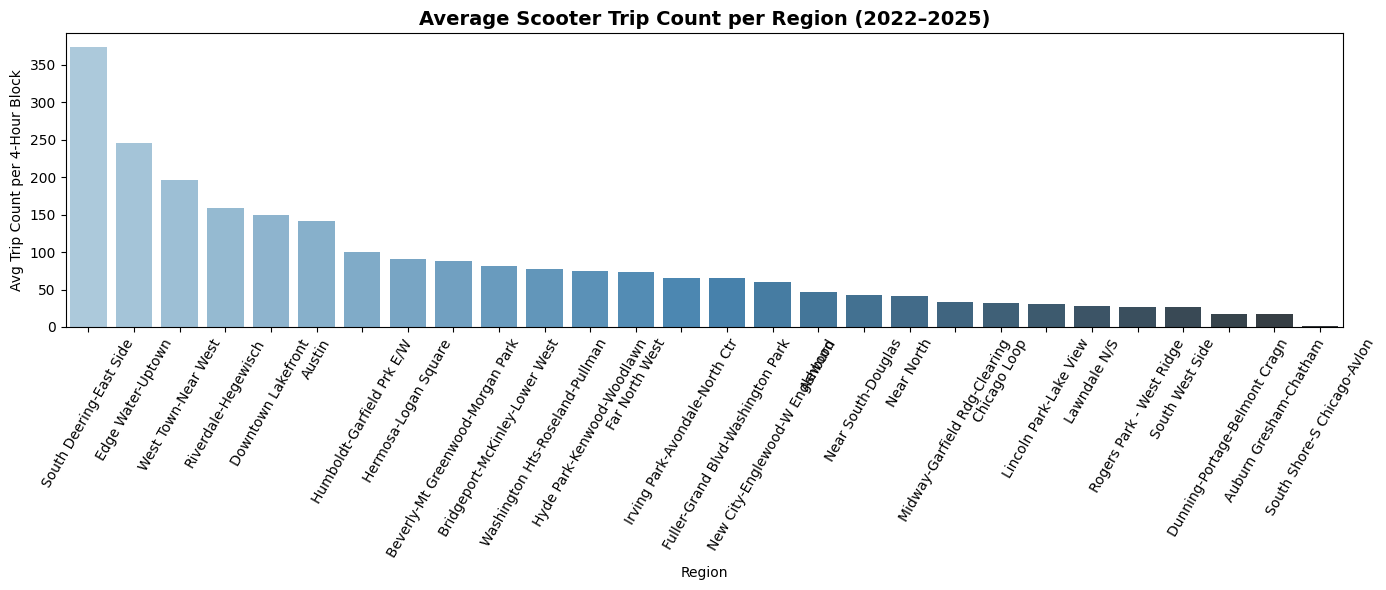


── 2. Average trip count per region per month ──
month_name                          Jan   Feb    Mar    Apr    May    Jun    Jul    Aug    Sep    Oct    Nov    Dec
region_name                                                                                                        
Ashburn                            15.3  13.6   25.5   40.8   57.9   57.2   44.9   57.3   61.6   58.2   51.9   36.6
Auburn Gresham-Chatham              5.7   6.3   11.3   16.6   22.8   20.1   16.2   18.0   21.0   25.6   19.6   12.0
Austin                             21.0  31.7   73.2  116.8  129.9  168.8  221.1  215.4  233.0  209.3  159.0   78.8
Beverly-Mt Greenwood-Morgan Park   27.9  25.3   42.4   67.2   92.5   94.3   96.2  105.8  123.1  127.1  111.3   83.6
Bridgeport-McKinley-Lower West     34.7  37.8   46.2   72.5   91.0   68.9   73.9   73.9   99.5  153.8  139.3   86.9
Chicago Loop                        7.8  12.0   17.1   25.1   25.6   28.7   44.9   50.6   54.0   51.1   38.0   16.1
Downtown Lakefront    

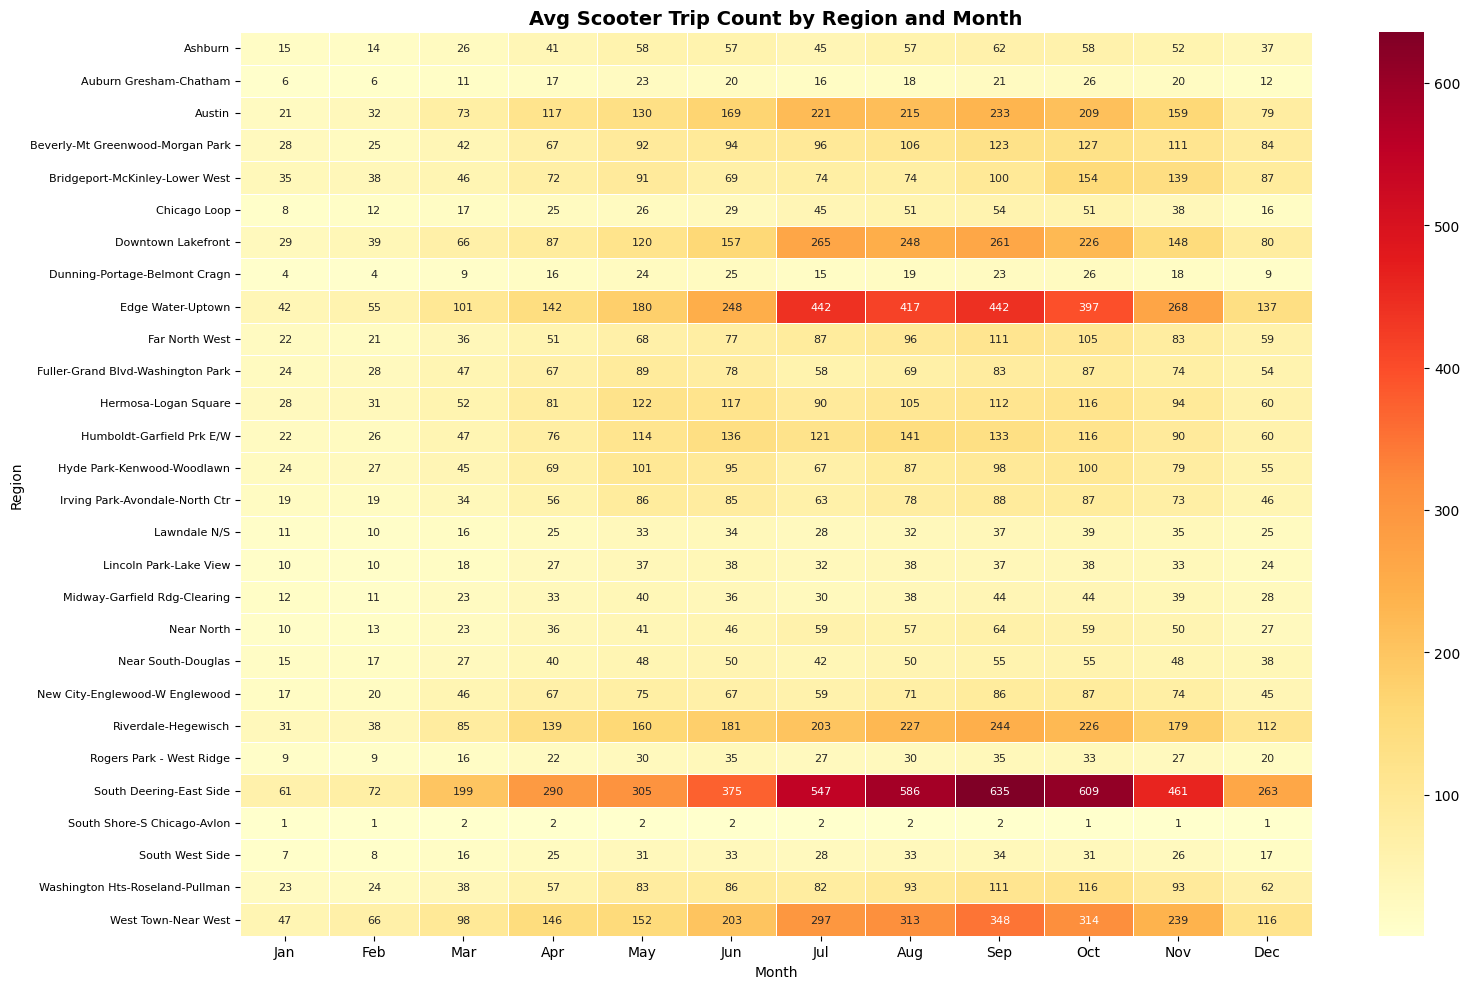

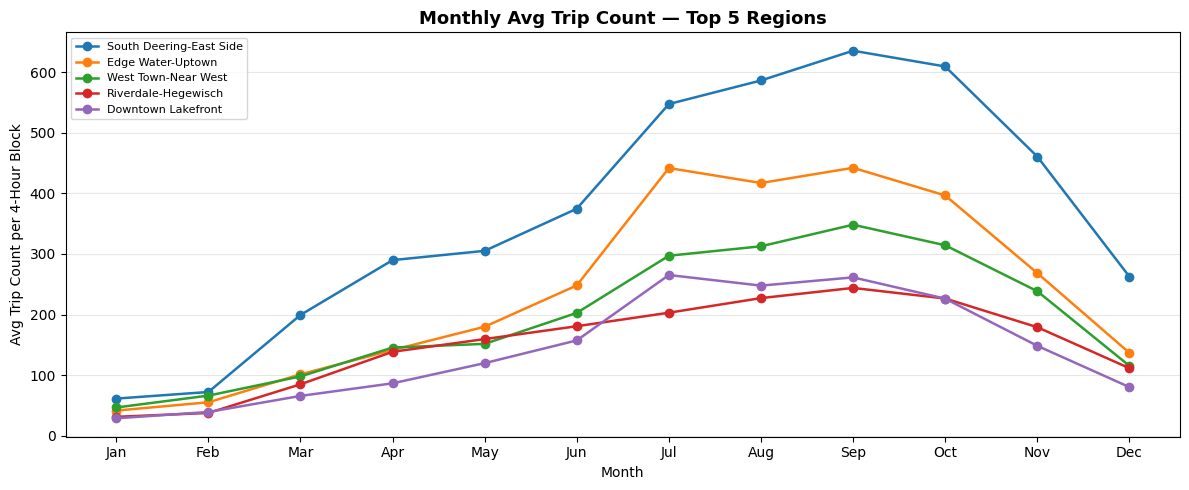


── 3. Average trip count per region per day of week ──
day_of_week                        Monday  Tuesday  Wednesday  Thursday  Friday  Saturday  Sunday
region_name                                                                                      
Ashburn                              44.8     45.2       45.2      49.3    54.6      45.7    40.7
Auburn Gresham-Chatham               16.6     16.8       16.7      17.6    20.9      17.5    15.1
Austin                              121.5    133.9      140.7     146.9   162.4     161.1   124.8
Beverly-Mt Greenwood-Morgan Park     91.9     85.1       84.4      86.0    96.0      89.1    81.2
Bridgeport-McKinley-Lower West       81.6     81.6       83.4      84.8    91.4      77.1    71.2
Chicago Loop                         30.7     31.2       30.9      32.0    34.6      32.7    29.0
Downtown Lakefront                  141.4    152.1      153.2     156.7   151.3     154.2   135.3
Dunning-Portage-Belmont Cragn        17.5     18.0       17.8 

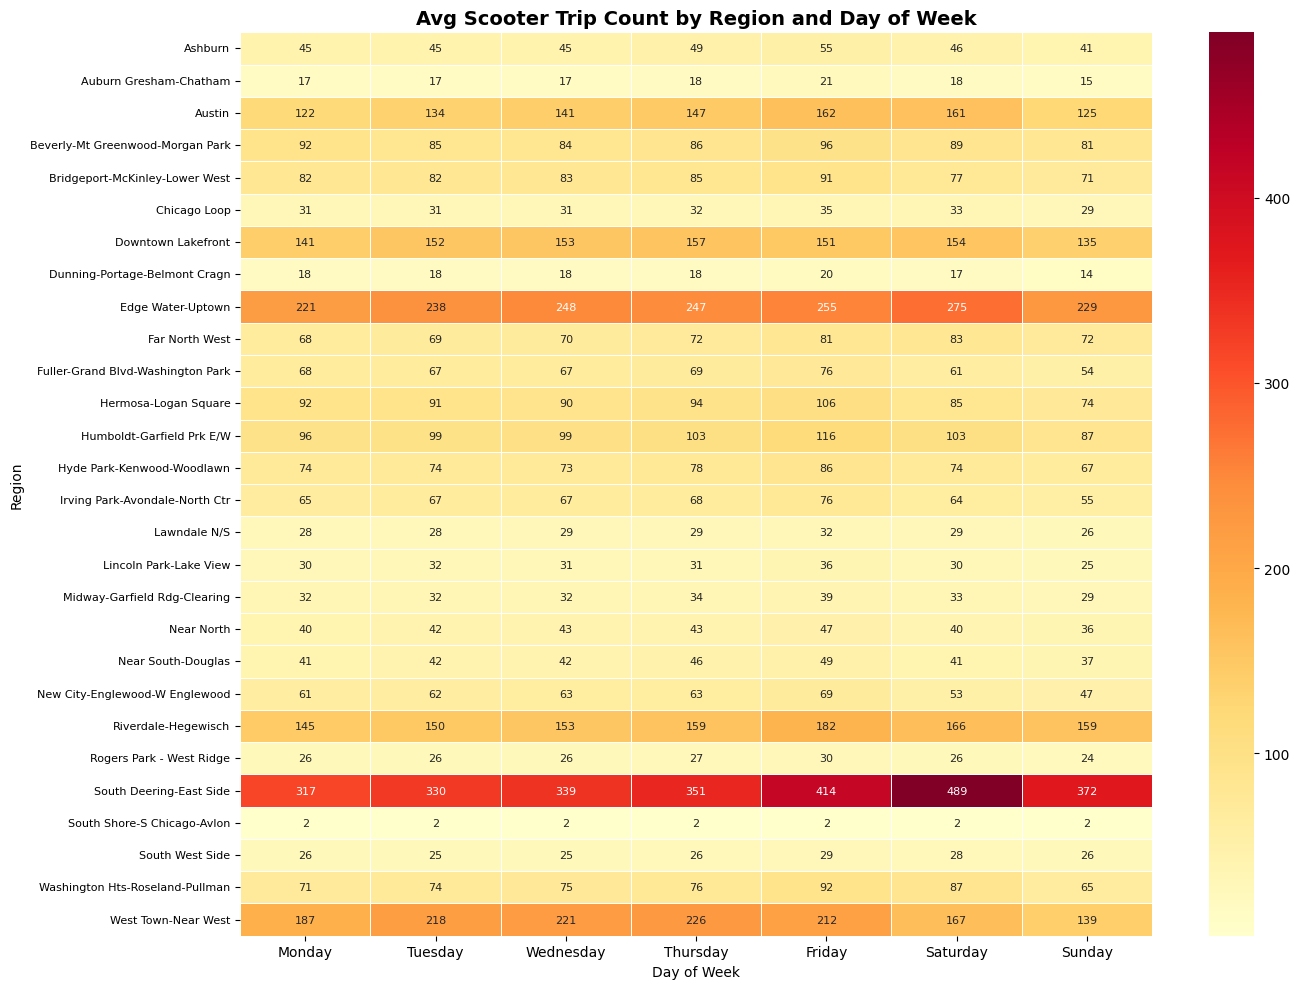

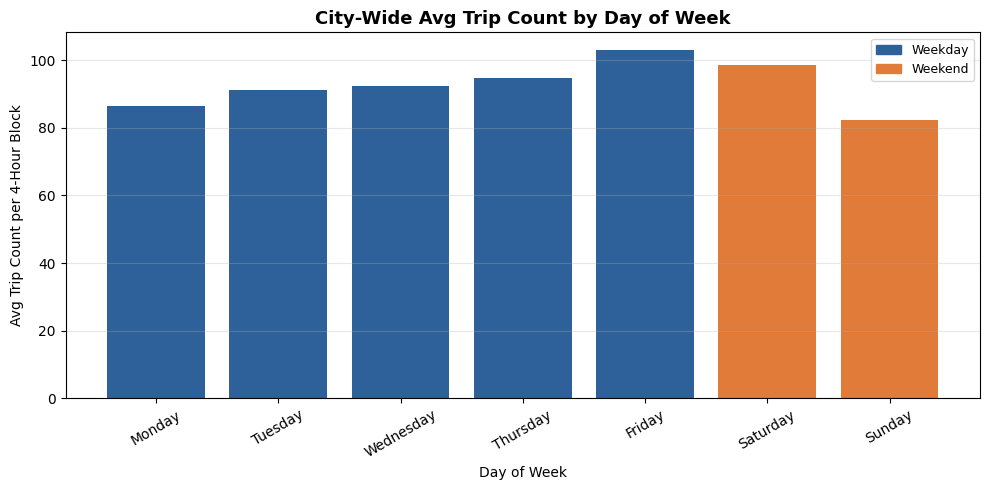


── 4. Average trip count per region per time block ──
time_block                         00:00-03:59  04:00-07:59  08:00-11:59  12:00-15:59  16:00-19:59  20:00-23:59
region_name                                                                                                    
Ashburn                                    4.4         12.6         44.8         69.8         87.7         50.9
Auburn Gresham-Chatham                     1.9          4.4         13.7         23.9         31.2         18.5
Austin                                    16.8         35.7        149.2        185.0        279.8        166.6
Beverly-Mt Greenwood-Morgan Park           9.6         20.6         79.2        125.8        162.4        108.3
Bridgeport-McKinley-Lower West             7.6         15.9         87.6        132.7        150.9         83.0
Chicago Loop                               3.8          5.9         28.9         45.5         58.1         36.6
Downtown Lakefront                        14.8   

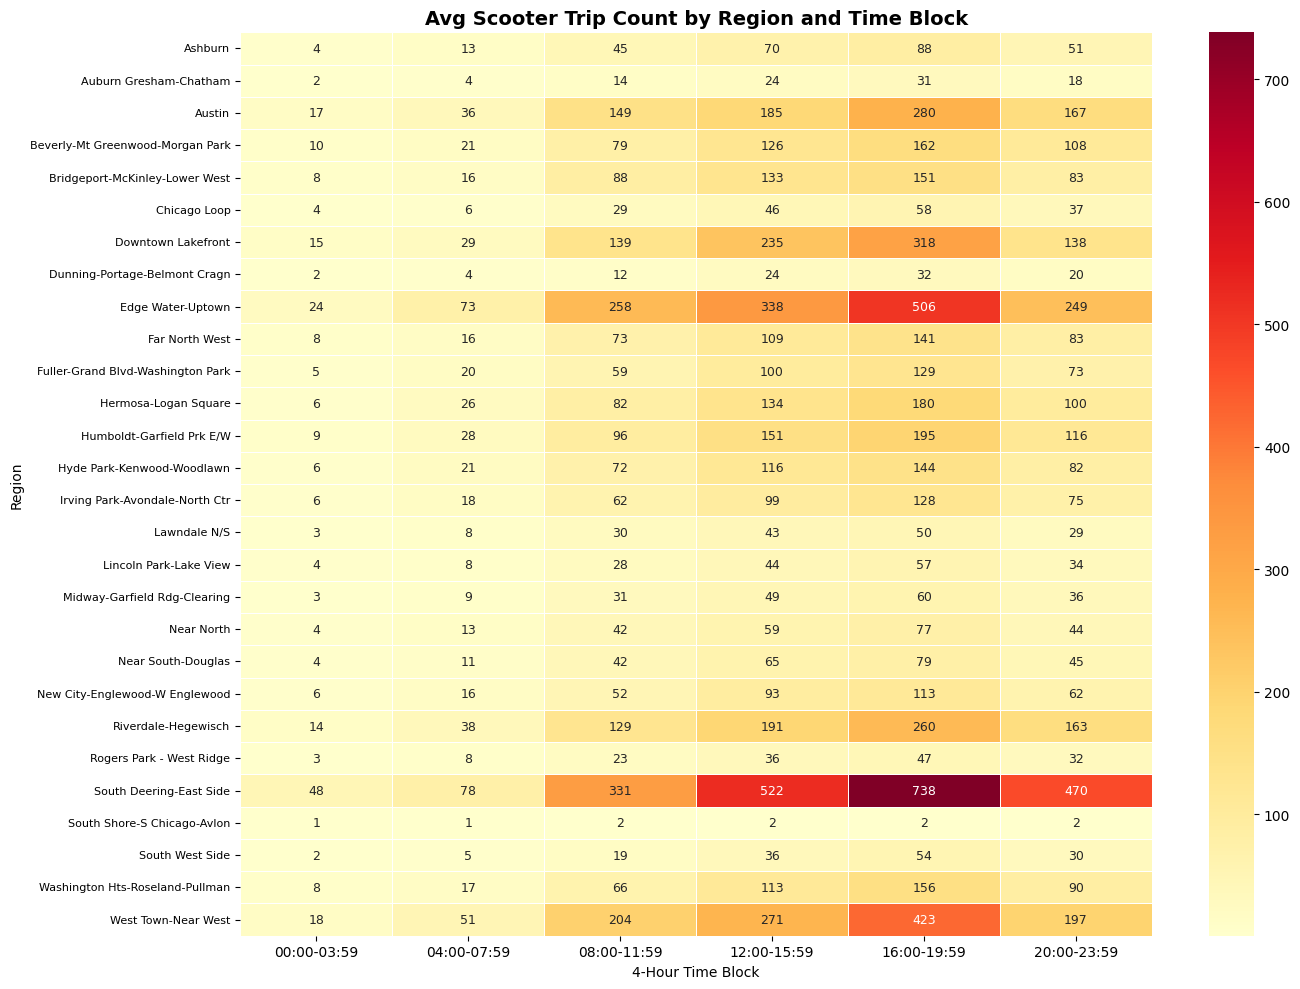

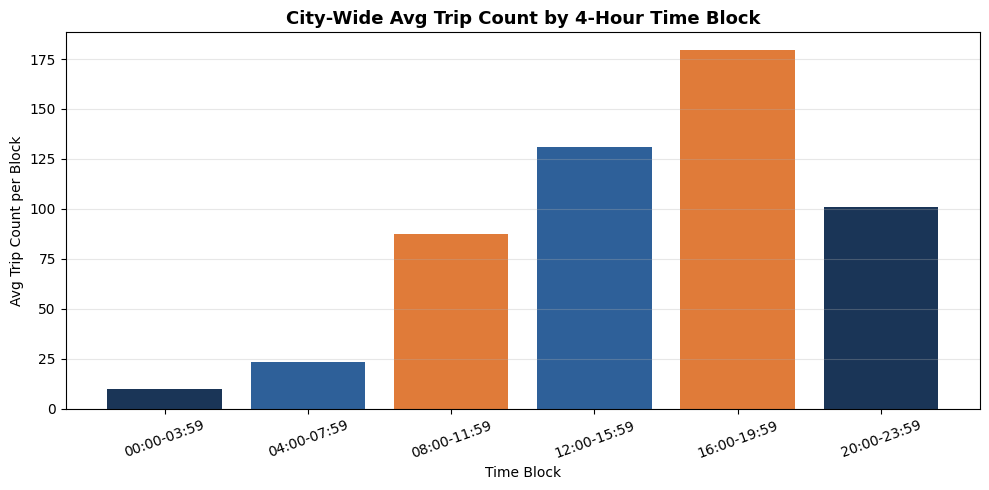


All EDA graphs saved to /graphs/ folder.


In [ ]:

#  EDA — TRIP COUNT ANALYSIS
#  1. Average trip count per region
#  2. Average trip count per region per month
#  3. Average trip count per region per day of week
#  4. Average trip count per region per time block (hour proxy)

# Re-parse date and extract time features from the merged dataset
merged['date_dt']     = pd.to_datetime(merged['date'], format='%m/%d/%Y')
merged['month']       = merged['date_dt'].dt.month
merged['month_name']  = merged['date_dt'].dt.strftime('%b')
merged['day_of_week'] = merged['date_dt'].dt.day_name()

# ── 1. Average trip count per region ─────────────────────────
print("── 1. Average trip count per region ──")

region_avg = (
    merged.groupby(['region_id', 'region_name'])['trip_count']
    .mean()
    .round(1)
    .reset_index()
    .sort_values('trip_count', ascending=False)
)
print(region_avg.to_string(index=False))

fig, ax = plt.subplots(figsize=(14, 6))
sns.barplot(
    data=region_avg,
    x='region_name', y='trip_count',
    palette='Blues_d', ax=ax
)
ax.set_title('Average Scooter Trip Count per Region (2022–2025)', fontsize=14, fontweight='bold')
ax.set_xlabel('Region')
ax.set_ylabel('Avg Trip Count per 4-Hour Block')
ax.tick_params(axis='x', rotation=60)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_by_region.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 2. Average trip count per region per month ───────────────
print("\n── 2. Average trip count per region per month ──")

month_order = ['Jan','Feb','Mar','Apr','May','Jun',
               'Jul','Aug','Sep','Oct','Nov','Dec']

region_month_avg = (
    merged.groupby(['region_name', 'month', 'month_name'])['trip_count']
    .mean()
    .round(1)
    .reset_index()
)
# For the table: pivot so regions are rows, months are columns
region_month_pivot = region_month_avg.pivot_table(
    index='region_name', columns='month_name', values='trip_count'
)[month_order]
print(region_month_pivot.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(16, 10))
sns.heatmap(
    region_month_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Avg Scooter Trip Count by Region and Month', fontsize=14, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Region')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_region_month.png', dpi=150, bbox_inches='tight')
plt.show()

# Line chart: top 5 regions by total trips across months
top5_regions = region_avg.head(5)['region_name'].tolist()
top5_monthly = region_month_avg[region_month_avg['region_name'].isin(top5_regions)]

fig, ax = plt.subplots(figsize=(12, 5))
for region in top5_regions:
    data = top5_monthly[top5_monthly['region_name'] == region].sort_values('month')
    ax.plot(data['month_name'], data['trip_count'], marker='o', linewidth=1.8, label=region)

ax.set_title('Monthly Avg Trip Count — Top 5 Regions', fontsize=13, fontweight='bold')
ax.set_xlabel('Month')
ax.set_ylabel('Avg Trip Count per 4-Hour Block')
ax.legend(fontsize=8, loc='upper left')
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_top5_monthly.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 3. Average trip count per region per day of week ─────────
print("\n── 3. Average trip count per region per day of week ──")

dow_order = ['Monday','Tuesday','Wednesday','Thursday','Friday','Saturday','Sunday']

region_dow_avg = (
    merged.groupby(['region_name', 'day_of_week'])['trip_count']
    .mean()
    .round(1)
    .reset_index()
)

# Pivot table
region_dow_pivot = region_dow_avg.pivot_table(
    index='region_name', columns='day_of_week', values='trip_count'
)[dow_order]
print(region_dow_pivot.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    region_dow_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 8}
)
ax.set_title('Avg Scooter Trip Count by Region and Day of Week', fontsize=14, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Region')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_region_dow.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart: city-wide average by day of week
citywide_dow = (
    merged.groupby('day_of_week')['trip_count']
    .mean()
    .reindex(dow_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
colors = ['#2E6099' if d not in ['Saturday','Sunday'] else '#E07B39' for d in dow_order]
ax.bar(citywide_dow['day_of_week'], citywide_dow['trip_count'], color=colors)
ax.set_title('City-Wide Avg Trip Count by Day of Week', fontsize=13, fontweight='bold')
ax.set_xlabel('Day of Week')
ax.set_ylabel('Avg Trip Count per 4-Hour Block')
ax.tick_params(axis='x', rotation=30)
ax.grid(axis='y', alpha=0.3)
# Legend
from matplotlib.patches import Patch
ax.legend(handles=[
    Patch(color='#2E6099', label='Weekday'),
    Patch(color='#E07B39', label='Weekend')
], fontsize=9)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_dow_citywide.png', dpi=150, bbox_inches='tight')
plt.show()


# ── 4. Average trip count per region per time block ──────────
print("\n── 4. Average trip count per region per time block ──")

block_order = ['00:00-03:59','04:00-07:59','08:00-11:59',
               '12:00-15:59','16:00-19:59','20:00-23:59']

region_block_avg = (
    merged.groupby(['region_name', 'time_block'])['trip_count']
    .mean()
    .round(1)
    .reset_index()
)

# Pivot table
region_block_pivot = region_block_avg.pivot_table(
    index='region_name', columns='time_block', values='trip_count'
)[block_order]
print(region_block_pivot.round(1).to_string())

# Heatmap
fig, ax = plt.subplots(figsize=(14, 10))
sns.heatmap(
    region_block_pivot,
    annot=True, fmt='.0f',
    cmap='YlOrRd',
    linewidths=0.5,
    ax=ax,
    annot_kws={'size': 9}
)
ax.set_title('Avg Scooter Trip Count by Region and Time Block', fontsize=14, fontweight='bold')
ax.set_xlabel('4-Hour Time Block')
ax.set_ylabel('Region')
ax.tick_params(axis='y', labelsize=8)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_region_timeblock.png', dpi=150, bbox_inches='tight')
plt.show()

# Bar chart: city-wide average by time block
citywide_block = (
    merged.groupby('time_block')['trip_count']
    .mean()
    .reindex(block_order)
    .reset_index()
)

fig, ax = plt.subplots(figsize=(10, 5))
block_colors = ['#1A3557','#2E6099','#E07B39','#2E6099','#E07B39','#1A3557']
ax.bar(citywide_block['time_block'], citywide_block['trip_count'], color=block_colors)
ax.set_title('City-Wide Avg Trip Count by 4-Hour Time Block', fontsize=13, fontweight='bold')
ax.set_xlabel('Time Block')
ax.set_ylabel('Avg Trip Count per Block')
ax.tick_params(axis='x', rotation=20)
ax.grid(axis='y', alpha=0.3)
plt.tight_layout()
plt.savefig('/content/drive/My Drive/data 400/graphs/trip_count_timeblock_citywide.png', dpi=150, bbox_inches='tight')
plt.show()

print("\nAll EDA graphs saved to /graphs/ folder.")

In [ ]:
# ── 5. Train / Test Split ─────────────────────────────────────
# Train: 2022, 2023, 2024
# Test:  2025

train = merged[merged['year'].isin([2022, 2023, 2024])].copy()
test  = merged[merged['year'] == 2025].copy()

print(f"\n── Train set (2022–2024) ──")
print(f"Rows: {len(train):,}")
print(f"Date range: {train['date'].iloc[0]} → {train['date'].iloc[-1]}")
print(train['year'].value_counts().sort_index())

print(f"\n── Test set (2025) ──")
print(f"Rows: {len(test):,}")
print(f"Date range: {test['date'].iloc[0]} → {test['date'].iloc[-1]}")

# Quick check: no data leakage between sets
assert set(train['year'].unique()).isdisjoint(set(test['year'].unique())), \
    "ERROR: years overlap between train and test!"
print("\nNo year overlap between train and test — split is clean.")



── Train set (2022–2024) ──
Rows: 94,188
Date range: 05/10/2022 → 12/31/2024
year
2022    25119
2023    30996
2024    38073
Name: count, dtype: int64

── Test set (2025) ──
Rows: 25,825
Date range: 01/01/2025 → 06/18/2025

No year overlap between train and test — split is clean.


In [ ]:
#view head of train set
train.head()

,date,time_block,region_id,region_name,description,trip_count,avg_distance_m,avg_duration_s,unique_vendors,avg_speed_mph,avg_bus_count,avg_num_reads,congestion_level,num_readings,year
0,05/10/2022,08:00-11:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,5,452.2,214.4,1,21.72,44.8,907.7,free_flow,24,2022
1,05/10/2022,12:00-15:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,9,494.5,468.0,1,20.78,39.9,813.0,free_flow,24,2022
2,05/10/2022,16:00-19:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,26,427.6,536.7,1,19.24,51.0,1001.0,moderate,24,2022
3,05/10/2022,20:00-23:59,4,Edge Water-Uptown,Montrose to Devon. Ravenswood to Lake Shore,10,83.0,509.7,1,22.86,23.9,526.3,free_flow,24,2022
4,05/10/2022,16:00-19:59,9,Austin,Roosevelt to North Ave. Austin to Cicero,4,20.5,265.7,1,24.40,25.9,551.4,free_flow,24,2022


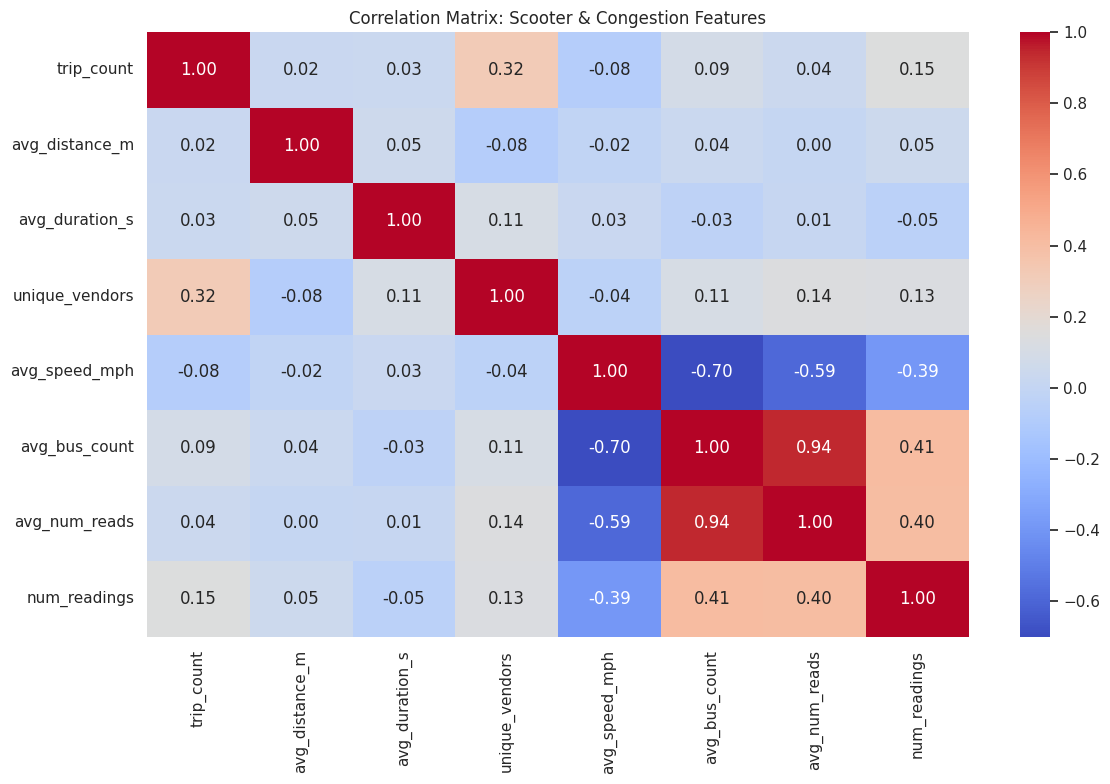

In [ ]:
# Select relevant numeric columns for the correlation matrix
numeric_cols = [
    'trip_count',
    'avg_distance_m',
    'avg_duration_s',
    'unique_vendors',
    'avg_speed_mph',
    'avg_bus_count',
    'avg_num_reads',
    'num_readings'
]

# Calculate correlation matrix
heat_corr = merged[numeric_cols].corr()

# Create heatmap
plt.figure(figsize=(12, 8))
sns.set(rc={'figure.facecolor':'w'})
# Using cmap='coolwarm' for better contrast and fmt='.2f' to round decimals
sns.heatmap(heat_corr, annot=True, cmap='coolwarm', fmt='.2f')
plt.title("Correlation Matrix: Scooter & Congestion Features")
plt.tight_layout()
plt.show()

                            OLS Regression Results                            
Dep. Variable:          avg_speed_mph   R-squared:                       0.007
Model:                            OLS   Adj. R-squared:                  0.007
Method:                 Least Squares   F-statistic:                     816.1
Date:                Tue, 28 Apr 2026   Prob (F-statistic):          6.78e-179
Time:                        19:36:23   Log-Likelihood:            -3.3774e+05
No. Observations:              120013   AIC:                         6.755e+05
Df Residuals:                  120011   BIC:                         6.755e+05
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
const         26.3501      0.013   2013.362      0.0

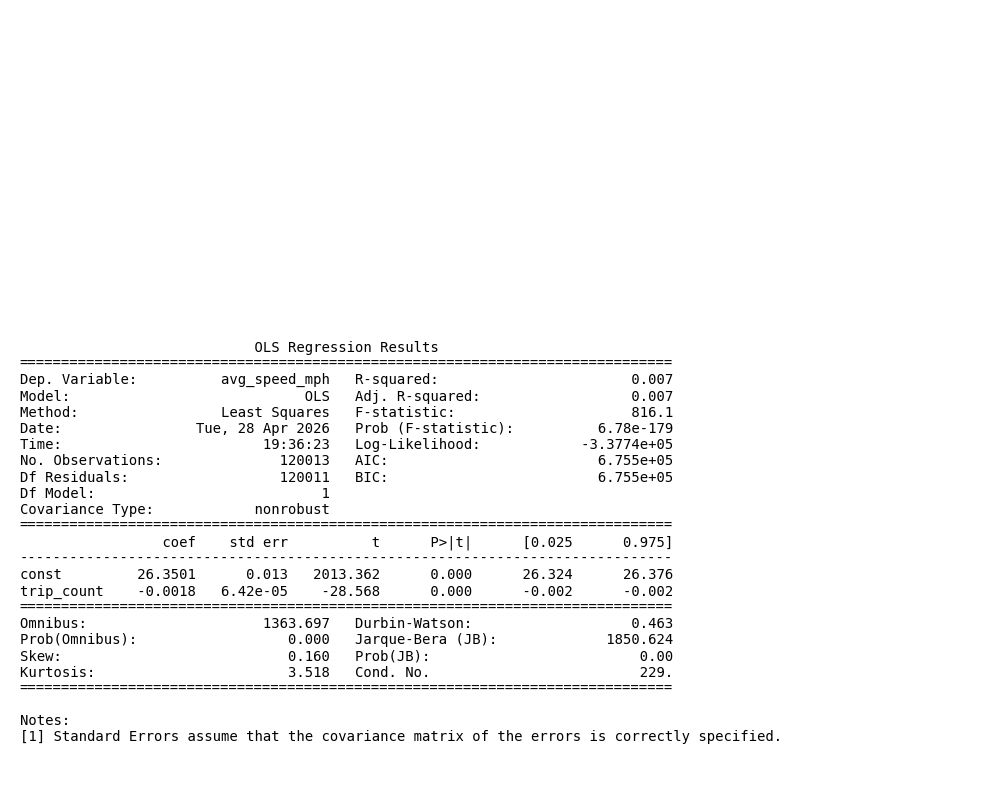

In [ ]:

# Drop NaNs created by missing values
reg_df = merged.dropna(subset=['trip_count', 'avg_speed_mph'])

# Define the independent variable (X) and dependent variable (y)
X = reg_df['trip_count']
y = reg_df['avg_speed_mph']

# Add a constant to the independent variable
X = sm.add_constant(X)

# Fit the linear regression model
model = sm.OLS(y, X).fit()

# Print the summary
summary_text = str(model.summary())
print(summary_text)

# Export summary as PNG
fig, ax = plt.subplots(figsize=(10, 8))
ax.text(0.01, 0.05, summary_text, {'fontsize': 10}, fontfamily='monospace')
ax.axis('off')
plt.tight_layout()
plt.savefig('regression_summary.png', bbox_inches='tight', dpi=300)
print("\nSummary saved as 'regression_summary.png'")
plt.show()

In [ ]:
# Step 1: Drop leakage features and insignificant ones
features = [
    'trip_count',
    'unique_vendors',
    'avg_bus_count',
    'num_readings'
]

X = reg_df[features].copy()
X = pd.concat([X, pd.get_dummies(reg_df['time_block'], prefix='tb', drop_first=True)], axis=1)
#X = pd.concat([X, pd.get_dummies(reg_df['region_id'], prefix='reg', drop_first=True)], axis=1)
X = pd.concat([X, pd.get_dummies(reg_df['congestion_level'], prefix='cong', drop_first=True)], axis=1)
X = X.astype(float)
X = sm.add_constant(X)

y = reg_df['avg_speed_mph']


model_clean = sm.OLS(y, X).fit(cov_type='HC3')
print(model_clean.summary())


vif = pd.DataFrame({
    'feature': X.columns,
    'VIF': [variance_inflation_factor(X.values, i) for i in range(X.shape[1])]
})
print(vif.sort_values('VIF', ascending=False).head(15))

#number of observation per region


                            OLS Regression Results                            
Dep. Variable:          avg_speed_mph   R-squared:                       0.588
Model:                            OLS   Adj. R-squared:                  0.588
Method:                 Least Squares   F-statistic:                 1.737e+04
Date:                Tue, 28 Apr 2026   Prob (F-statistic):               0.00
Time:                        19:50:27   Log-Likelihood:            -2.8499e+05
No. Observations:              120013   AIC:                         5.700e+05
Df Residuals:                  120001   BIC:                         5.701e+05
Df Model:                          11                                         
Covariance Type:                  HC3                                         
                     coef    std err          z      P>|z|      [0.025      0.975]
----------------------------------------------------------------------------------
const             32.2790      0.056    573.

In [ ]:
effect_per_1k = model_clean.params['trip_count'] * 1000
ci_low  = model_clean.conf_int().loc['trip_count', 0] * 1000
ci_high = model_clean.conf_int().loc['trip_count', 1] * 1000
print(f"Effect per +1,000 trips: {effect_per_1k:.4f} mph (95% CI: [{ci_low:.4f}, {ci_high:.4f}])")

Effect per +1,000 trips: 0.0841 mph (95% CI: [0.0436, 0.1246])


In [ ]:
# Build full feature set
def build_X(df, include_trip_count=True):
    cols = ['unique_vendors', 'avg_bus_count', 'num_readings']
    if include_trip_count:
        cols = ['trip_count'] + cols
    X = df[cols].copy()
    for c in ['time_block', 'region_id', 'congestion_level']:
        X = pd.concat([X, pd.get_dummies(df[c], prefix=c, drop_first=True)], axis=1)
    return X.astype(float)

# Model WITH trip_count
X_train_full = build_X(train, include_trip_count=True)
X_test_full  = build_X(test,  include_trip_count=True).reindex(columns=X_train_full.columns, fill_value=0)

# Model WITHOUT trip_count
X_train_no   = build_X(train, include_trip_count=False)
X_test_no    = build_X(test,  include_trip_count=False).reindex(columns=X_train_no.columns,  fill_value=0)

y_train, y_test = train['avg_speed_mph'], test['avg_speed_mph']

params = dict(n_estimators=500, max_depth=8, learning_rate=0.05,
              subsample=0.8, colsample_bytree=0.8, random_state=42, n_jobs=-1)

m_full = XGBRegressor(**params).fit(X_train_full, y_train)
m_no   = XGBRegressor(**params).fit(X_train_no,   y_train)

p_full = m_full.predict(X_test_full)
p_no   = m_no.predict(X_test_no)

print(f"{'Model':<25}{'MAE':>10}{'RMSE':>10}{'R²':>10}")
print("-" * 55)
print(f"{'WITH trip_count':<25}{mean_absolute_error(y_test, p_full):>10.4f}"
      f"{np.sqrt(mean_squared_error(y_test, p_full)):>10.4f}{r2_score(y_test, p_full):>10.4f}")
print(f"{'WITHOUT trip_count':<25}{mean_absolute_error(y_test, p_no):>10.4f}"
      f"{np.sqrt(mean_squared_error(y_test, p_no)):>10.4f}{r2_score(y_test, p_no):>10.4f}")

# How much does trip_count actually contribute?
r2_gain = r2_score(y_test, p_full) - r2_score(y_test, p_no)
mae_drop = mean_absolute_error(y_test, p_no) - mean_absolute_error(y_test, p_full)
print(f"\n→ Adding trip_count improves R² by {r2_gain:.5f}")
print(f"→ Adding trip_count reduces MAE by {mae_drop:.5f} mph")

Model                           MAE      RMSE        R²
-------------------------------------------------------
WITH trip_count              0.7094    1.0584    0.9286
WITHOUT trip_count           0.7075    1.0571    0.9288

→ Adding trip_count improves R² by -0.00017
→ Adding trip_count reduces MAE by -0.00195 mph


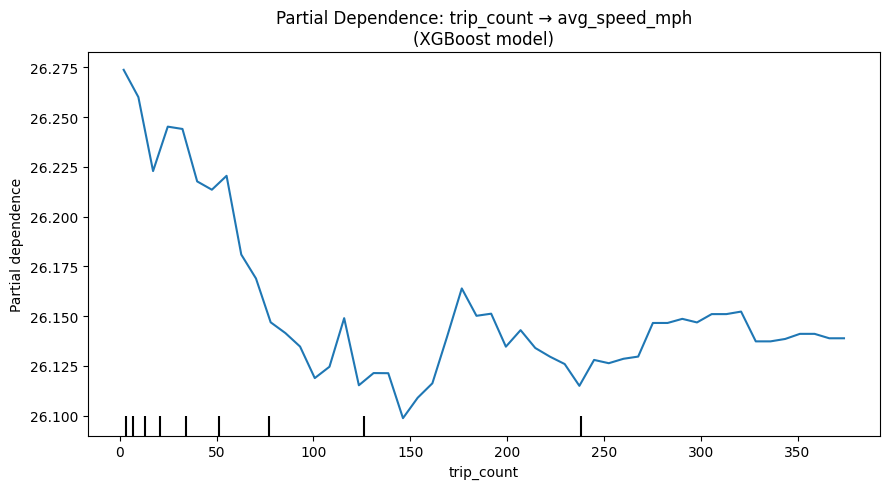

In [ ]:
fig, ax = plt.subplots(figsize=(9, 5))
PartialDependenceDisplay.from_estimator(
    m_full, X_train_full, features=['trip_count'],
    grid_resolution=50, ax=ax
)
ax.set_title('Partial Dependence: trip_count → avg_speed_mph\n(XGBoost model)')
ax.set_xlabel('Scooter trip count')
ax.set_ylabel('Predicted speed (mph)')
ax.grid(alpha=0.3)
plt.tight_layout()
plt.show()